# Load and Plot from a File {#read_file_exercise}

Read a dataset from a known file type.


We try to make loading a mesh as easy as possible - if your data is in
one of the many supported file formats, simply use
`pyvista.read`{.interpreted-text role="func"} to load your spatially
referenced dataset into a PyVista mesh object.

The following code block uses a built-in example file and displays an
airplane mesh.


In [1]:
import pyvista as pv
from pyvista import examples

c:\Users\Usuario\anaconda3\envs\VAD\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
help(pv.read)

Help on function read in module pyvista.core.utilities.fileio:

read(
    filename: 'PathStrSeq',
    force_ext: 'str | None' = None,
    file_format: 'str | None' = None,
    progress_bar: 'bool' = False,
    *,
    cls: 'type[DataObject] | None' = None,
    validate: 'bool | None' = None
) -> 'DataObject'
    Read any file type supported by ``vtk`` or ``meshio``.

    Automatically determines the correct reader to use then wraps the
    corresponding mesh as a pyvista object.  Attempts native ``vtk``
    readers first then tries to use ``meshio``. :py:mod:`Pickled<pickle>`
    meshes (``'.pkl'`` or ``'.pickle'``) are also supported.

    Remote URIs (``https://``, ``s3://``, etc.) are downloaded to a
    temporary file automatically.  Install ``fsspec`` for full protocol
    support (``pip install pyvista[io]``); ``pooch`` is used as a
    fallback for HTTP(S).  Third-party reader plugins registered via
    :func:`pyvista.register_reader` are also checked.

    See :func:`pyvista.get

PyVista supports a wide variety of file formats. The supported file
extensions are listed in an internal function:

See
<https://docs.pyvista.org/api/readers/_autosummary/pyvista.get_reader#pyvista.get_reader>


In [3]:
help(pv.core.utilities.reader.get_reader)

Help on function get_reader in module pyvista.core.utilities.reader:

get_reader(filename, force_ext=None)
    Get a reader for fine-grained control of reading data files.

    Supported file types and Readers:

    .. include:: /api/readers/readers_table.rst

    Parameters
    ----------
    filename : str, Path
        The string path to the file to read.

    force_ext : str, optional
        An extension to force a specific reader to be chosen.

    Returns
    -------
    pyvista.BaseReader
        A subclass of :class:`pyvista.BaseReader` is returned based on file type.

    Examples
    --------
    >>> import pyvista as pv
    >>> from pyvista import examples
    >>> from pathlib import Path
    >>> filename = examples.download_human(load=False)
    >>> Path(filename).name
    'Human.vtp'
    >>> reader = pv.get_reader(filename)
    >>> reader
    XMLPolyDataReader('...Human.vtp')
    >>> mesh = reader.read()
    >>> mesh
    PolyData ...
    >>> mesh.plot(color='lightblue')



The following code block uses a built-in example file, displays an
airplane mesh and returns the camera\'s position:


In [4]:
# Get a sample file
filename = examples.planefile
filename

'C:\\Users\\Usuario\\anaconda3\\envs\\VAD\\Lib\\site-packages\\pyvista\\examples\\airplane.ply'

Note the above filename, it\'s a `.ply` file - one of the many supported
formats in PyVista.

Use `pv.read` to load the file as a mesh:


C:\Users\Usuario\AppData\Local\Temp\ipykernel_13528\3224243515.py:2: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  cpos = mesh.plot()


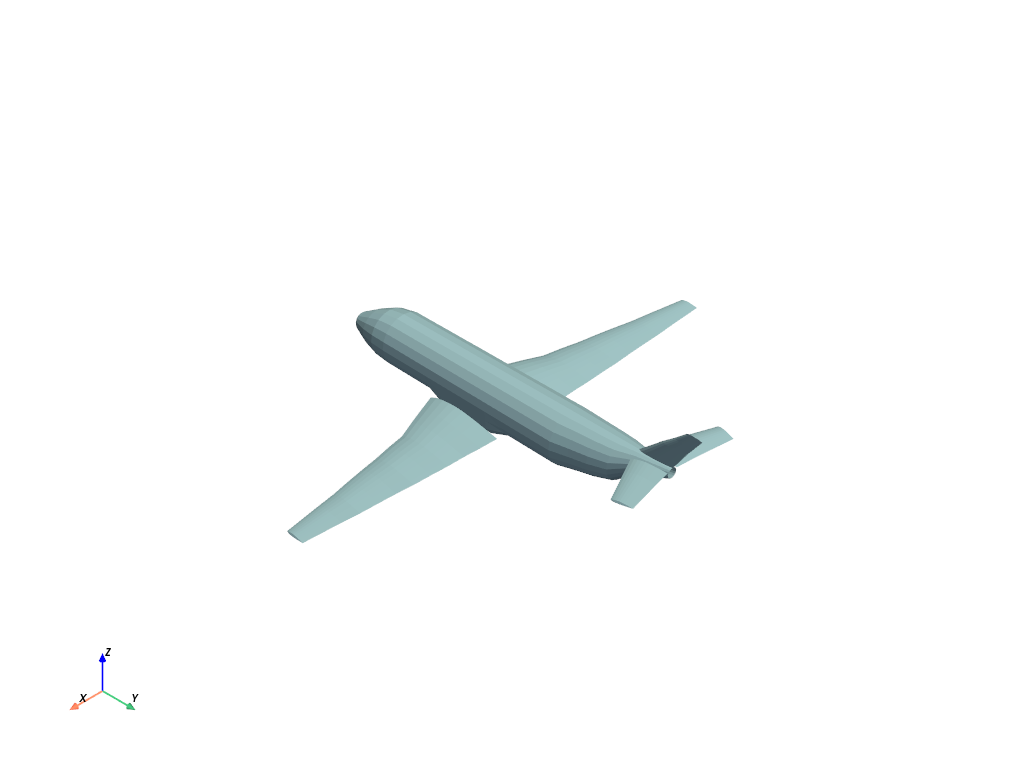

In [5]:
mesh = pv.read(filename)
cpos = mesh.plot()

The points from the mesh are directly accessible as a NumPy array:


In [6]:
mesh.points

pyvista_ndarray([[896.994  ,  48.7601 ,  82.2656 ],
                 [906.593  ,  48.7601 ,  80.7452 ],
                 [907.539  ,  55.4902 ,  83.6581 ],
                 ...,
                 [806.665  , 627.363  ,   5.11482],
                 [806.665  , 654.432  ,   7.51998],
                 [806.665  , 681.537  ,   9.48744]],
                shape=(1335, 3), dtype=float32)

The faces from the mesh are also directly accessible as a NumPy array:


In [7]:
mesh.faces.reshape(-1, 4)[:, 1:]  # triangular faces

array([[   0,    1,    2],
       [   0,    2,    3],
       [   4,    5,    1],
       ...,
       [1324, 1333, 1323],
       [1325, 1216, 1334],
       [1325, 1334, 1324]], shape=(2452, 3))

Loading other files types is just as easy! Simply pass your file path to
the `pyvista.read`{.interpreted-text role="func"} function and that\'s
it!

Here are a few other examples - simply replace `examples.download_*` in
the examples below with `pyvista.read('path/to/you/file.ext')`

We have a gallery of the example datasets available here:
<https://docs.pyvista.org/api/examples/dataset_gallery>


Example STL file:


C:\Users\Usuario\AppData\Local\Temp\ipykernel_13528\1618216668.py:3: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  mesh.plot(cpos=cpos)


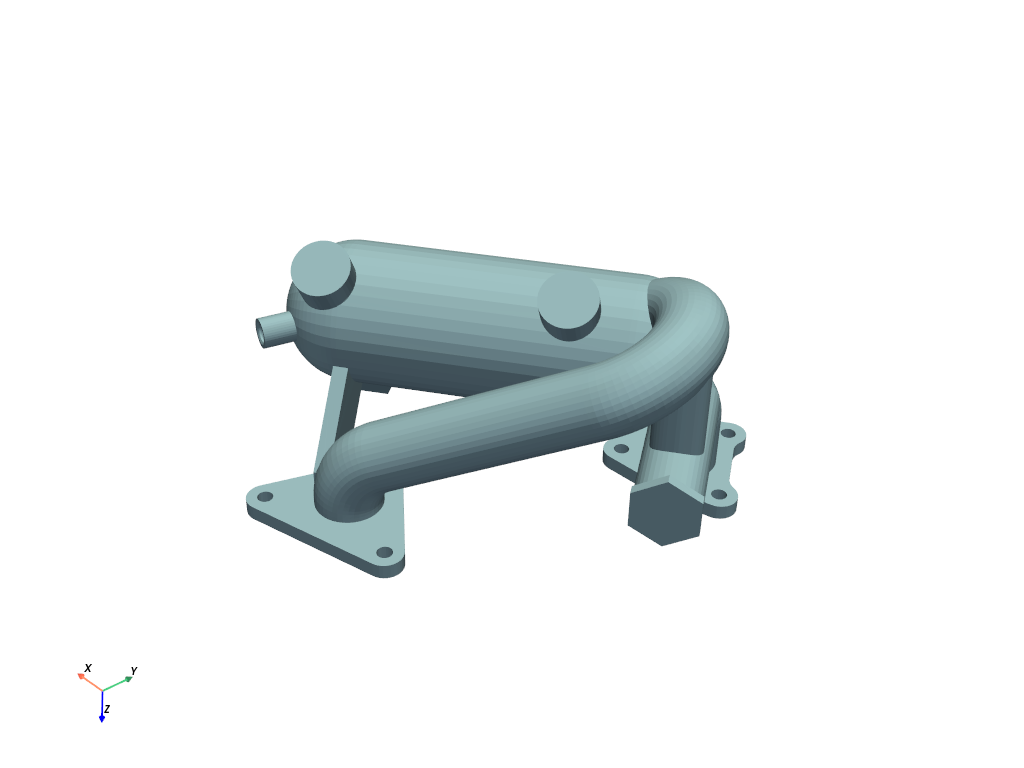

In [8]:
mesh = examples.download_cad_model()
cpos = [(107.0, 68.5, 204.0), (128.0, 86.5, 223.5), (0.45, 0.36, -0.8)]
mesh.plot(cpos=cpos)

Example OBJ file


C:\Users\Usuario\AppData\Local\Temp\ipykernel_13528\2655548285.py:2: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  mesh.plot(cpos="xy")


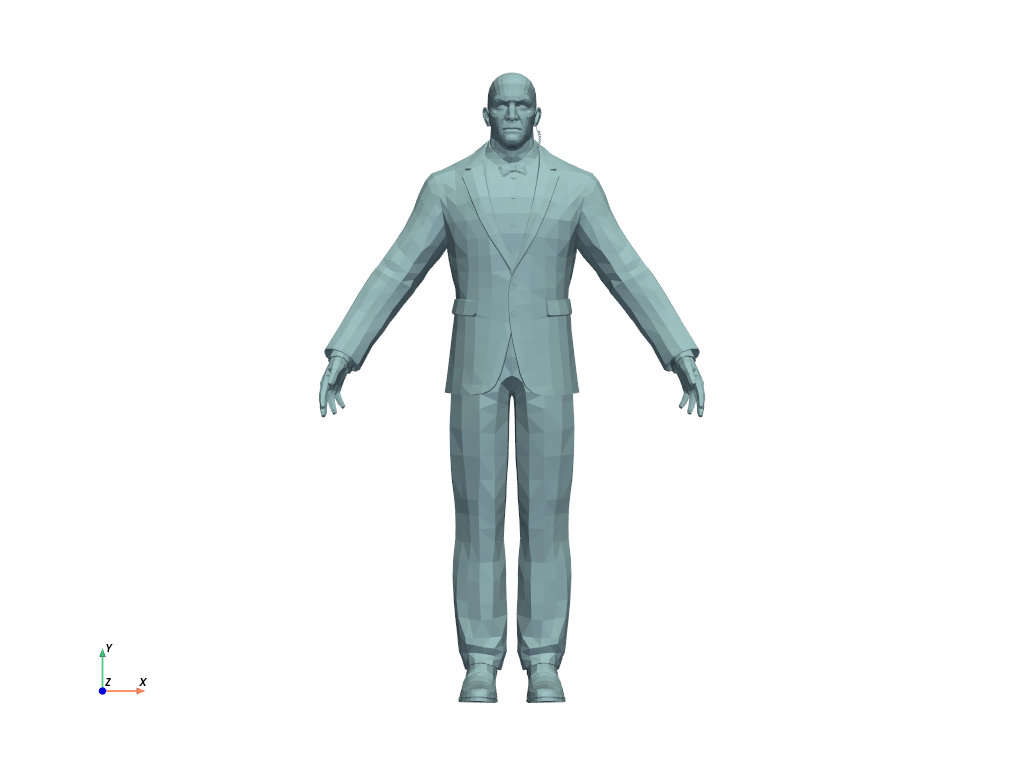

In [9]:
mesh = examples.download_doorman()
mesh.plot(cpos="xy")

Example BYU file


C:\Users\Usuario\AppData\Local\Temp\ipykernel_13528\1697557396.py:2: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  mesh.plot(cpos=[-1, 2, -5], show_edges=True)


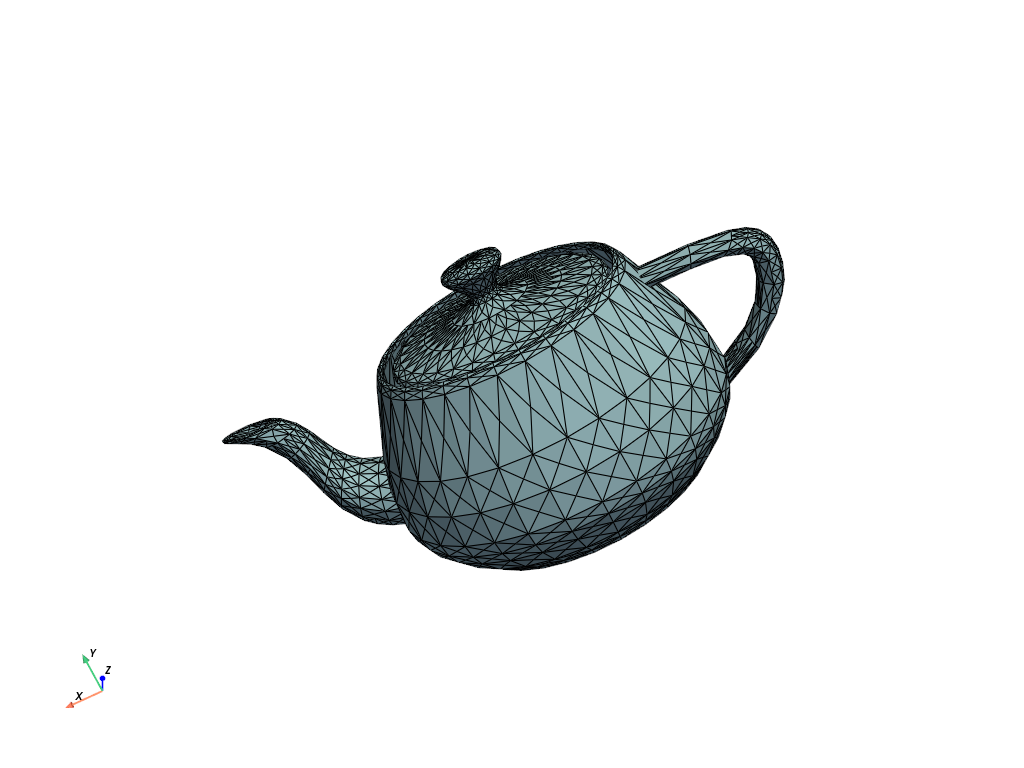

In [10]:
mesh = examples.download_teapot()
mesh.plot(cpos=[-1, 2, -5], show_edges=True)

Example VTK file


C:\Users\Usuario\AppData\Local\Temp\ipykernel_13528\117212898.py:3: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  mesh.plot(cpos=cpos, show_edges=True, color=True)


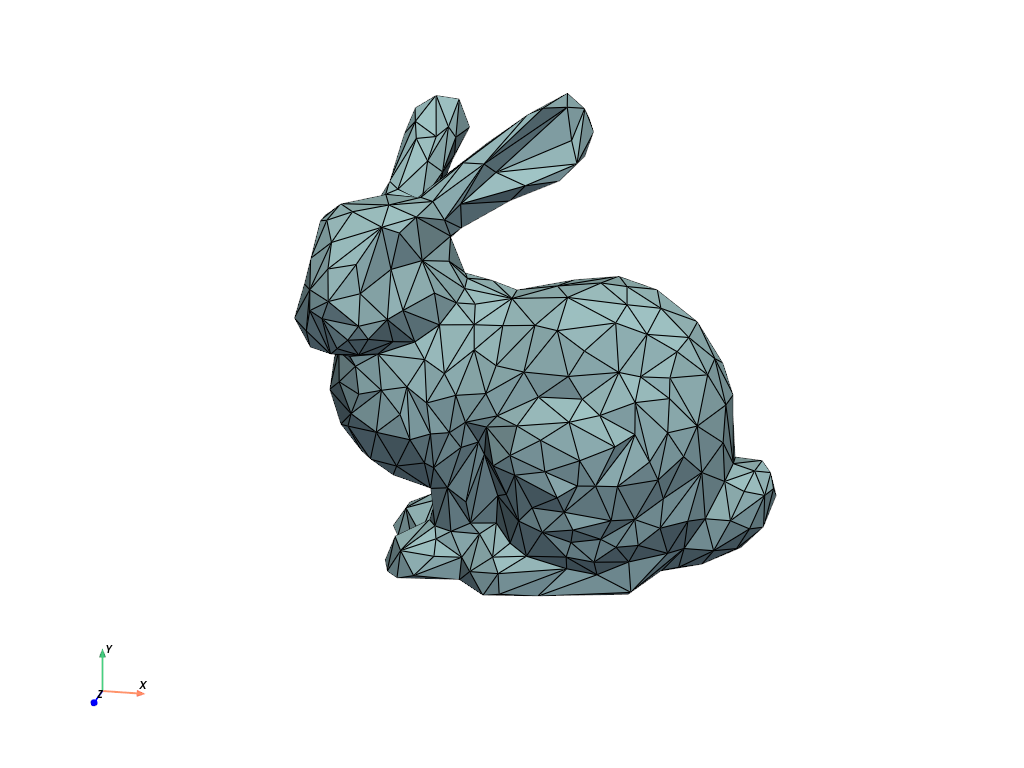

In [11]:
mesh = examples.download_bunny_coarse()
cpos = [(0.2, 0.3, 0.9), (0, 0, 0), (0, 1, 0)]
mesh.plot(cpos=cpos, show_edges=True, color=True)

# Exercise

Read a file yourself with `pyvista.read`{.interpreted-text role="func"}.
If you have a supported file format, use that! Otherwise, download this
file:
<https://github.com/pyvista/pyvista-tutorial/raw/main/tutorial/02_mesh/scipy.vtk>


C:\Users\Usuario\AppData\Local\Temp\ipykernel_13528\1563402777.py:4: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  mesh.plot(show_edges=True)


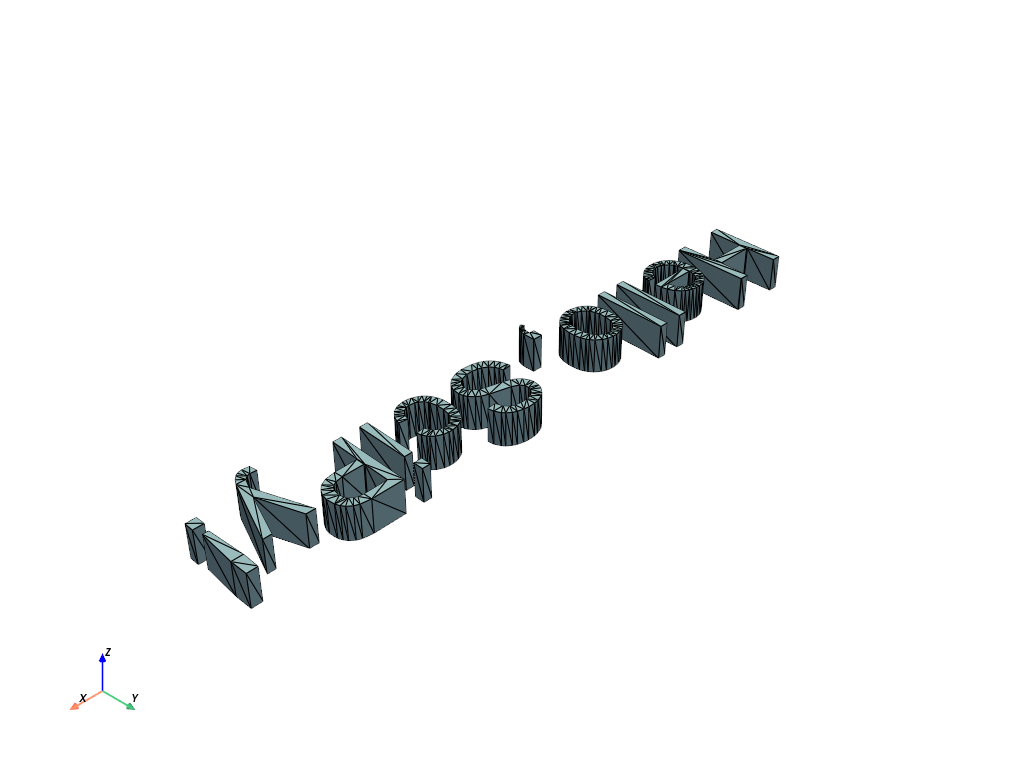

In [13]:
# (your code here)
ruta_local = "./scipy.vtk"
mesh = pv.read(ruta_local)
mesh.plot(show_edges=True)

```{=html}
<center>
  <a target="_blank" href="https://colab.research.google.com/github/pyvista/pyvista-tutorial/blob/gh-pages/notebooks/tutorial/02_mesh/exercises/e_read-file.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/ width="150px">
  </a>
</center>
```
